# 08 — Support Vector Machine (RBF)

## Introducción

**Objetivo.** Entrenar, evaluar e interpretar **Support Vector Machine (RBF)** en el marco *screening* (honesto).

**Fundamento teórico.** Maximiza el margen entre clases; el kernel RBF permite fronteras no lineales.

**Ventajas.** Eficaz en espacios de alta dimensión; fronteras flexibles.

**Limitaciones.** Escala mal (O(n²)) — aquí se submuestrea; sensible al escalado; probabilidades vía Platt.

**Casos de uso.** Conjuntos pequeños/medianos con fronteras complejas.


In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('../src'))
import warnings; warnings.simplefilter('ignore')
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
from predia_ml import config, data, evaluate, plots
pd.set_option('display.max_columns', 60)


In [2]:
NAME = 'svm'
sp = joblib.load(config.DATASETS_DIR/'split_screening.joblib')
X_test, y_test = sp['X_test'], sp['y_test']
est = joblib.load(config.MODELS_DIR/f'screening_{NAME}.joblib')
meta = json.load(open(config.METRICS_DIR/f'screening_{NAME}.json'))
print('Mejores hiperparámetros:'); print(json.dumps(meta['best_params'], indent=2))
print('CV ROC AUC:', round(meta['cv_roc_auc'],4), '| fit_time(s):', meta['fit_time_sec'], '| submuestreo:', meta['subsampled'])

Mejores hiperparámetros:
{
  "clf__C": 0.14936568554617632,
  "clf__gamma": "auto",
  "clf__kernel": "rbf"
}
CV ROC AUC: 0.636 | fit_time(s): 244.11 | submuestreo: True


### Evaluación en test (recalculada en ejecución)

In [3]:
y_pred = est.predict(X_test); y_proba = est.predict_proba(X_test)[:,1]
m = evaluate.compute_metrics(y_test, y_pred, y_proba)
pd.Series({k: round(v,4) for k,v in m.items()}).to_frame('valor')

,valor
accuracy,0.6123
balanced_accuracy,0.5254
precision,0.6130
recall_sensitivity,0.9600
specificity,0.0907
f1,0.7482
mcc,0.1044
tn,726.0000
fp,7274.0000
fn,480.0000


### Curvas ROC, Precision-Recall, matriz de confusión y calibración

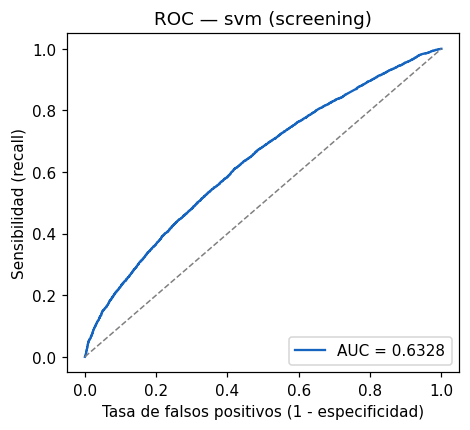

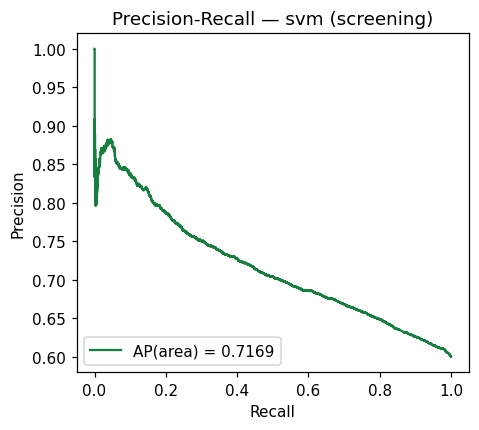

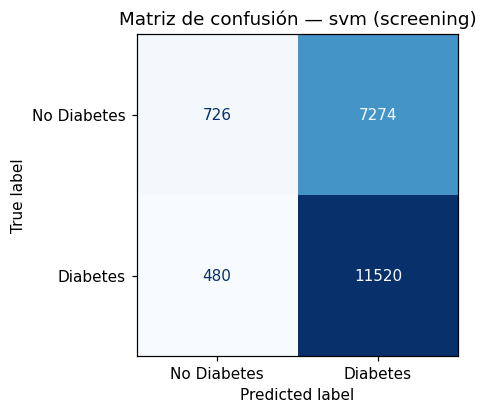

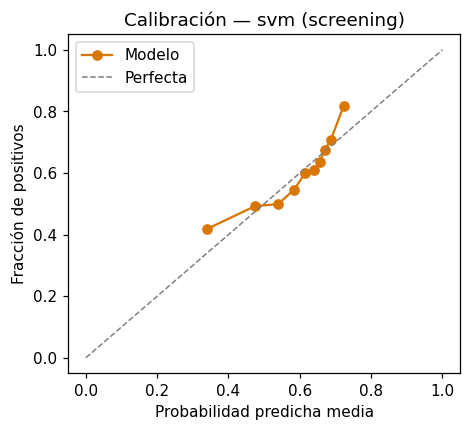

In [4]:
for kind in ['roc','pr','cm','cal']:
    p = config.FIGURES_DIR/'models'/f'{kind}_screening_{NAME}.png'
    if p.exists(): display(Image(filename=str(p)))